### Testing script of the CNN model
#### TODO:

+ THink of why accuracy goes down again after dropout 0.1! (might be okay due to fairly small model)
+ Why Adam and not AdamW? 
+ Create requirments file!
+ ToDo: Run the cnns on different padding (0, 1, 3) and kernel size as well (3x3, 5x5, 7x7) with Epoch 10 (so six runs) and then write down why we decided for the most part on the 3x3 and 1 (if the output serves us right)
+ Run one iteration on GPU just to see time difference for report

**At the end**
+ Make it all in a script to be run from command line
+ Add argument parsing for hyperparameters


**To include in the report**
+ Trained two CNNs with difference in how they would be able to handle differently sized images. However, since the Dataloader of PyTorch doesnt really support that (except for with some tweaks that are really not necessary for this exercise, changing how the batches are passed essentially), it was decided to not analyze things like runtime and accuracy further with the second dataset. We already got an idea of the performance and will hence only use SimpleCNN for the first model now
+ Big learning out of the above: We ofc learned that Feed-Forward networks only really take fixed sized inputs, but we tried anyhow to make it work but yeah simply wasted time then haha



### Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

# Local imports
from cnn import SimpleCNN, SimpleAdaptiveCNN
from data.load_cifar import CIFAR10
from train import train_model
from analysis.evaluation import evaluate_model
from data.load_gtsrb import GTSRB_CLASSES, GTSRB


# https://medium.com/@BurtMcGurt/a-practical-guide-to-data-augmentation-in-pytorch-with-examples-and-visualizations-761ad5c2a903
# https://docs.pytorch.org/vision/0.21/transforms.html
import torchvision.transforms as transforms
from torchvision.transforms import v2

import matplotlib.pyplot as plt
import numpy as np

## CIFAR related Area

### Training Area

In [ ]:
# Device selection (prep for potential GPU usage in e.g Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data Augmentation
train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(),
    v2.RandomCrop(32, padding=4), # padding is ofc applied dbefore cropping randomly
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3)
])
#train_transforms = None
val_transforms = None

# Create datasets
train_dataset = CIFAR10(split="train", transform=train_transforms)
test_dataset  = CIFAR10(split="test", transform=val_transforms)

# Class names in CIFAR-10
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck" ]

# Create dataloaders
trainloader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valloader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

# check the "batching"
images, labels = next(iter(trainloader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

In [ ]:
in_channels = 3
num_classes = 10
input_size = 32
base_channels = 32
channel_multiplier = 2
epochs=20

model_selection = {"SimpleCNN_dropout_05": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                input_size=input_size,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.5), 
                    "SimpleCNN_dropout_04": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.4),
                    "SimpleCNN_dropout_03": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.3), 
                    "SimpleCNN_dropout_02": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.2), 
                    "SimpleCNN_dropout_01": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.1),   
                    "SimpleCNN_dropout_00": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.0)       
                                }

for model_name, model in model_selection.items():
    print(f"Training model: {model_name}")
    # Set the model to the device (GPU/CPU)
    model = model.to(device)
    print(model)

    # Prepare Loss function and optimizer
    criterion = nn.CrossEntropyLoss() # loss function cross entropy that will be used for calculating the loss during training so that the optimizer can update the weights accordingly (remember backpropagation!)

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    print("Starting training...")
    # Train the model
    trained_model = train_model(
        model=model,
        trainloader=trainloader,
        valloader=valloader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        epochs=epochs
        )
    print("Training completed.")    

    # Save the trained model and check for exisiting files/dirs 
    Path("cnn_trained_models").mkdir(exist_ok=True)
    file_name = f"cnn_trained_models/{model_name.lower()}_cifar10.pth"
    
    # Check if file exists and append version number
    base_path = Path(file_name)
    if base_path.exists():
        version = 1
        while (base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}").exists():
            version += 1
        file_name = str(base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}")

    torch.save(trained_model.state_dict(), file_name)
    print("Saved trained model to:", file_name)
    
    print("Evaluating trained model on validation set...")
    trained_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = trained_model(images)
            _, preds = outputs.max(1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    print(f"Final validation accuracy: {correct / total:.4f}")

    evaluate_model(trained_model, valloader, device=device, class_names=class_names)

    del trained_model

### Show here the training and validation times of our models 
Dropout at 0.5, only things changed is augmentation on/off and the comparison between the two CNN models over number of Epochs

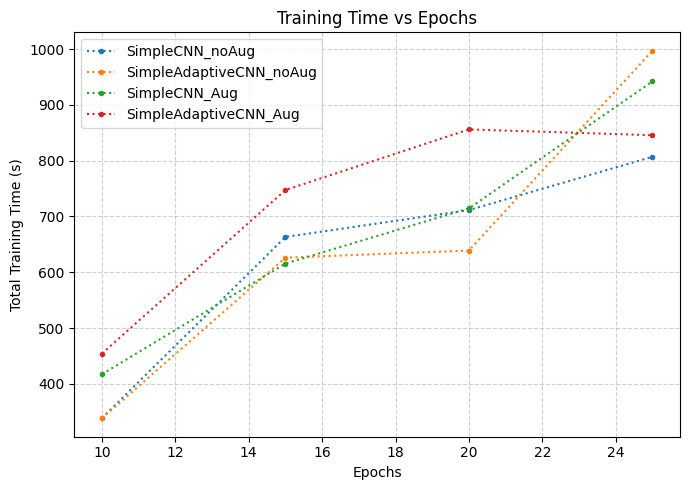

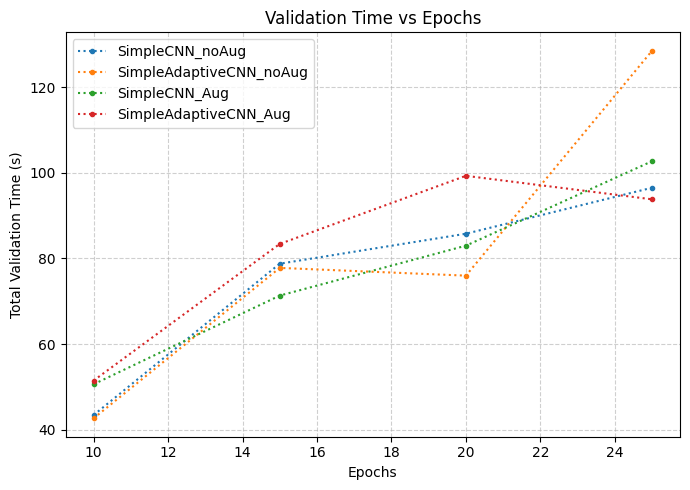

In [6]:
train_val_times = {   
    #/cnn_trained_models/Ten_epochs and /cnn_training_curves/Ten_epochs
    "SimpleCNN_10Epochs_noAug": {
        "Total Training Time": 338.53 ,
        "Total Validation Time": 43.4 
        } ,
    "SimpleAdaptiveCNN_10Epochs_noAug":{
        "Total Training Time"  : 338.12 ,
        "Total Validation Time": 42.64
        },
    "SimpleCNN_10Epochs_Aug": {
        "Total Training Time"  : 417.16,
        "Total Validation Time": 50.60
        },
    "SimpleAdaptiveCNN_10Epochs_Aug" : {
        "Total Training Time" : 454.24,
        "Total Validation Time": 51.46,
        },

    # /cnn_trained_models/Fifteen_epochs and /cnn_training_curves/Fifteen_epochs
    "SimpleCNN_15Epochs_noAug": {
        "Total Training Time"  : 663.27,
        "Total Validation Time": 78.77
        },
    "SimpleAdaptiveCNN_15Epochs_noAug": {
        "Total Training Time"  : 626.09,
        "Total Validation Time": 77.79
        },
    "SimpleCNN_15Epochs_Aug": {
        "Total Training Time"  : 615.57,
        "Total Validation Time": 71.32
        },
    "SimpleAdaptiveCNN_15Epochs_Aug": {
        "Total Training Time"  : 747.35,
        "Total Validation Time": 83.39
        },

    # /cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twenty_epochs
    "SimpleCNN_20Epochs_noAug": {
        "Total Training Time"  : 711.45,
        "Total Validation Time": 85.77
        },
    "SimpleAdaptiveCNN_20Epochs_noAug": {
        "Total Training Time"  : 638.99,
        "Total Validation Time": 75.98
        },

    "SimpleCNN_20Epochs_Aug": {
        "Total Training Time"  : 714.55,
        "Total Validation Time": 82.98
        },
    "SimpleAdaptiveCNN_20Epochs_Aug": {
        "Total Training Time"  : 856.05,
        "Total Validation Time": 99.3
        },

    # /cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twentyfive_epochs
    "SimpleCNN_25Epochs_noAug":{
        "Total Training Time"  : 807.0,
        "Total Validation Time": 96.52
    },
    "SimpleAdaptiveCNN_25Epochs_noAug": {
        "Total Training Time"  : 997.14,
        "Total Validation Time": 128.53
    },

    "SimpleCNN_25Epochs_Aug": {
        "Total Training Time"  : 942.12,
        "Total Validation Time": 102.72
        },

    "SimpleAdaptiveCNN_25Epochs_Aug": {
        "Total Training Time"  : 845.66,
        "Total Validation Time": 93.81
        }
}


# Epochs
epochs = [10, 15, 20, 25]

# Extracted data in order of epochs above
train_times = {
    "SimpleCNN_noAug": [338.53, 663.27, 711.45, 807.0],
    "SimpleAdaptiveCNN_noAug": [338.12, 626.09, 638.99, 997.14],
    "SimpleCNN_Aug": [417.16, 615.57, 714.55, 942.12],
    "SimpleAdaptiveCNN_Aug": [454.24, 747.35, 856.05, 845.66],
}

val_times = {
    "SimpleCNN_noAug": [43.4, 78.77, 85.77, 96.52],
    "SimpleAdaptiveCNN_noAug": [42.64, 77.79, 75.98, 128.53],
    "SimpleCNN_Aug": [50.60, 71.32, 82.98, 102.72],
    "SimpleAdaptiveCNN_Aug": [51.46, 83.39, 99.3, 93.81],
}

# Training time plot
plt.figure(figsize=(7, 5))
for label, values in train_times.items():
    plt.plot(epochs, values, marker=".", label=label, linestyle=":")

plt.xlabel("Epochs")
plt.ylabel("Total Training Time (s)")
plt.title("Training Time vs Epochs")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Validation time plot
plt.figure(figsize=(7, 5))
for label, values in val_times.items():
    plt.plot(epochs, values, marker=".", label=label, linestyle=":")

plt.xlabel("Epochs")
plt.ylabel("Total Validation Time (s)")
plt.title("Validation Time vs Epochs")
plt.legend()
plt.grid(True,linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Show here the final validation error of the models from before

**Meaning of the suffices**

/cnn_trained_models/Ten_epochs and /cnn_training_curves/Ten_epochs
+ _wo_normalization: There we did not normalize the img in Load_Cifar with std and dev
+ v1: without data augmentation
+ v2: with data augmentation

/cnn_trained_models/Fifteen_epochs and /cnn_training_curves/Fifteen_epochs
+ no suffix: without data augmentation
+ v1: with data augmentation

/cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twenty_epochs
+ no suffix: without data augmentation
+ v1: with data augmentation

/cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twentyfive_epochs
+ no suffix: without data augmentation
+ v1: with data augmentation

In [ ]:
in_channels = 3
num_classes = 10
input_size = 32
base_channels = 32
channel_multiplier = 2

models = {
    'SimpleCNN_10Epochs_noNorm': 'Ten_Epochs/simplecnn_cifar10_wo_normalization.pth', 'SimpleAdaptiveCNN_10Epochs_noNorm': 'Ten_Epochs/simpleadaptivecnn_cifar10_wo_normalization.pth', 
    'SimpleCNN_10Epochs_noAug': 'Ten_Epochs/simplecnn_cifar10_v1.pth', 'SimpleAdaptiveCNN_10Epochs_noAug': 'Ten_Epochs/simpleadaptivecnn_cifar10_v1.pth', 
    'SimpleCNN_10Epochs_Aug': 'Ten_Epochs/simplecnn_cifar10_v2.pth', 'SimpleAdaptiveCNN_10Epochs_Aug': 'Ten_Epochs/simpleadaptivecnn_cifar10_v2.pth', 

    'SimpleCNN_15Epochs_noAug': 'Fifteen_Epochs/simplecnn_cifar10.pth', 'SimpleAdaptiveCNN_15Epochs_noAug': 'Fifteen_Epochs/simpleadaptivecnn_cifar10.pth', 
    'SimpleCNN_15Epochs_Aug': 'Fifteen_Epochs/simplecnn_cifar10_v1.pth', 'SimpleAdaptiveCNN_15Epochs_Aug': 'Fifteen_Epochs/simpleadaptivecnn_cifar10_v1.pth', 

    'SimpleCNN_20Epochs_noAug': 'Twenty_Epochs/simplecnn_cifar10.pth', 'SimpleAdaptiveCNN_20Epochs_noAug': 'Twenty_Epochs/simpleadaptivecnn_cifar10.pth', 
    'SimpleCNN_20Epochs_Aug': 'Twenty_Epochs/simplecnn_cifar10_v1.pth', 'SimpleAdaptiveCNN_20Epochs_Aug': 'Twenty_Epochs/simpleadaptivecnn_cifar10_v1.pth', 

    'SimpleCNN_25Epochs_noAug': 'Twentyfive_Epochs/simplecnn_cifar10.pth', 'SimpleAdaptiveCNN_25Epochs_noAug': 'Twentyfive_Epochs/simpleadaptivecnn_cifar10.pth', 
    'SimpleCNN_25Epochs_Aug': 'Twentyfive_Epochs/simplecnn_cifar10_v1.pth', 'SimpleAdaptiveCNN_25Epochs_Aug': 'Twentyfive_Epochs/simpleadaptivecnn_cifar10_v1.pth'
    }


validation_error = {}
for key, value in models.items():
    if "SimpleCNN" in key:
        trained_model = SimpleCNN(in_channels=in_channels, 
                          num_classes=num_classes, 
                          input_size=input_size,
                          base_channels=base_channels, 
                          channel_multiplier=channel_multiplier,
                          dropout_rate=0.5)
    elif "SimpleAdaptiveCNN" in key:
        trained_model = SimpleAdaptiveCNN(in_channels=in_channels, 
                                  num_classes=num_classes, 
                                  input_size=input_size,
                                  base_channels=base_channels, 
                                  channel_multiplier=channel_multiplier,
                                  dropout_rate=0.5)
        
    filename = value
    trained_model.load_state_dict(torch.load(f"cnn_trained_models/CIFAR/{filename}"))

    trained_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = trained_model(images)
            _, preds = outputs.max(1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    print(f"Final validation accuracy for {key}: {correct / total:.4f}")
    validation_error[key] = correct / total

In [ ]:
print(validation_error)

epochs = [10, 15, 20, 25]
data = {
    "SimpleCNN_noAug": [0.771, 0.7693, 0.7741, 0.7732],
    "SimpleCNN_Aug": [0.7587, 0.7845, 0.7992, 0.8104],
    "SimpleAdaptiveCNN_noAug": [0.7199, 0.7493, 0.7632, 0.7649],
    "SimpleAdaptiveCNN_Aug": [0.6832, 0.7214, 0.7477, 0.7617],
}

plt.figure(figsize=(8, 5))

for label, values in data.items():
    plt.plot(epochs, values, marker=".", linestyle="--", linewidth=1, label=label)

    for x, y in zip(epochs, values): 
        plt.text(
            x, 
            y + 0.002, 
            f"{y:.3f}",
            ha="center", va="bottom", fontsize=8)
        
plt.xlabel("Epochs")
plt.ylabel("Validation Error")
plt.title("Validation Error vs Epochs")
plt.legend()
plt.grid(linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


### Plotting here the impact of dropout

Dropout tested: [0.5, 0.4, 0.3, 0.2, 0.1, 0.0]. Other "variables" set: Augmentation on and 20 Epochs

In [ ]:
dropout_model_accuracy = {
    "SimpleCNN_dropout_05": 0.7913, 
    "SimpleCNN_dropout_04": 0.7977, 
    "SimpleCNN_dropout_03": 0.7938,       
    "SimpleCNN_dropout_02": 0.8003,
    "SimpleCNN_dropout_01": 0.8146,   
    "SimpleCNN_dropout_00": 0.8002
    }

# (train, val)        
dropout_model_training_validation_time = {               
    "SimpleCNN_dropout_05": (757.07, 86.77), 
    "SimpleCNN_dropout_04": (743.74, 82.23), 
    "SimpleCNN_dropout_03": (716.00, 78.37),       
    "SimpleCNN_dropout_02": (735.72, 80.42),  
    "SimpleCNN_dropout_01": (879.49, 100.24),
    "SimpleCNN_dropout_00": (893.26, 100.07)
    }


# Extract dropout values from the name
dropout_values = np.array([int(k[-2:]) / 10 for k in dropout_model_accuracy.keys()])
accuracies = np.array(list(dropout_model_accuracy.values()))

# Accuracy Plot
plt.figure(figsize=(7, 3))
plt.plot(dropout_values, accuracies, marker=".", linestyle="--", linewidth=1)

plt.xlabel("Dropout Rate")
plt.ylabel("Accuracy")
plt.title("Accuracy of SimpleCNN (20 Epochs) vs Dropout")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(dropout_values)
plt.tight_layout()
plt.show()

# Training & Validation Time Plot
train_times = [v[0] for v in dropout_model_training_validation_time.values()]
val_times = [v[1] for v in dropout_model_training_validation_time.values()]

plt.figure(figsize=(7, 3))
plt.plot(dropout_values, train_times, marker=".", linestyle="--", linewidth=1, label="Training Time")

plt.xlabel("Dropout Rate")
plt.ylabel("Time (seconds)")
plt.title("Training vs Dropout")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(dropout_values)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3))
plt.plot(dropout_values, val_times, marker=".", linestyle="--", linewidth=1, label="Validation Time")

plt.xlabel("Dropout Rate")
plt.ylabel("Time (seconds)")
plt.title("Validation vs Dropout")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(dropout_values)
plt.tight_layout()
plt.show()

## GTSRB related Area

### Training Area

In [2]:
# Device selection (prep for potential GPU usage in e.g Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data Augmentation
train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(),
    v2.RandomCrop(64, padding=4), # padding is ofc applied dbefore cropping randomly
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3)
])
#train_transforms = None 
val_transforms = None

training_path = "../data/GTSRB/Final_Training/Images"
testing_path = "../data/GTSRB/Final_Test/Images"

# Create datasets
train_dataset = GTSRB(base_path=training_path, split="train", transform=train_transforms)
test_dataset  = GTSRB(base_path=testing_path, split="test", transform=None)

# Class names in GTSRB
class_names = list(GTSRB_CLASSES.values())

# Create dataloaders
trainloader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valloader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

# check the "batching"
images, labels = next(iter(trainloader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

#Using device: cpu
#Loading GTSRB (train) from ../data/GTSRB/Final_Training/Images...
#Loading GTSRB (test) from ../data/GTSRB/Final_Test/Images...
#Train samples: 39209
#Test samples: 12630
#Image batch shape: torch.Size([128, 3, 64, 64])
#Label batch shape: torch.Size([128])
#Image dtype: torch.float32
#Label dtype: torch.int64

Using device: cpu
Loading GTSRB (train) from ../data/GTSRB/Final_Training/Images...
Loading GTSRB (test) from ../data/GTSRB/Final_Test/Images...
Train samples: 39209
Test samples: 12630


/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Image batch shape: torch.Size([128, 3, 64, 64])
Label batch shape: torch.Size([128])
Image dtype: torch.float32
Label dtype: torch.int64


Training model: SimpleCNN_dropout_05
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=8192, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=43, bias=True)
  )
)
Starting training...

Epoch 1/20


Train Loss: 2.1344 | Train Acc: 0.3611
Train Time: 91.68s
Val   Loss: 1.1702 | Val   Acc: 0.6063
Val   Time: 13.72s

Epoch 2/20


Train Loss: 1.0170 | Train Acc: 0.6549
Train Time: 83.83s
Val   Loss: 0.5815 | Val   Acc: 0.8127
Val   Time: 12.55s

Epoch 3/20


Train Loss: 0.6067 | Train Acc: 0.7934
Train Time: 84.73s
Val   Loss: 0.4016 | Val   Acc: 0.8683
Val   Time: 12.68s

Epoch 4/20


Train Loss: 0.4213 | Train Acc: 0.8582
Train Time: 83.32s
Val   Loss: 0.3240 | Val   Acc: 0.8954
Val   Time: 12.51s

Epoch 5/20


...

Train Loss: 0.0925 | Train Acc: 0.9692
Train Time: 102.50s
Val   Loss: 0.2265 | Val   Acc: 0.9557
Val   Time: 17.43s

Epoch 17/20


Train Loss: 0.0881 | Train Acc: 0.9706
Train Time: 104.28s
Val   Loss: 0.2029 | Val   Acc: 0.9538
Val   Time: 16.11s

Epoch 18/20


Train Loss: 0.0814 | Train Acc: 0.9725
Train Time: 115.41s
Val   Loss: 0.2112 | Val   Acc: 0.9502
Val   Time: 19.74s

Epoch 19/20


Train Loss: 0.0757 | Train Acc: 0.9741
Train Time: 115.58s
Val   Loss: 0.2267 | Val   Acc: 0.9523
Val   Time: 17.92s

Epoch 20/20


Train Loss: 0.0796 | Train Acc: 0.9739
Train Time: 137.55s
Val   Loss: 0.1909 | Val   Acc: 0.9564
Val   Time: 21.98s

Total Training Time  : 2003.03s
Total Validation Time: 318.62s


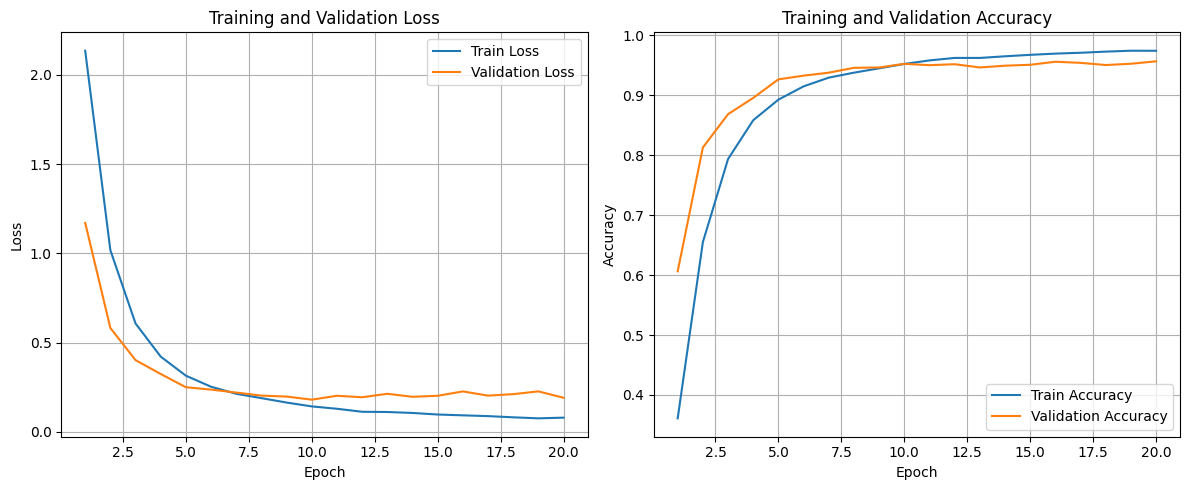

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_dropout_05_gtsrb.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.9564

Model Evaluation
----------------
Overall accuracy: 0.9564

Per-class accuracy:
  Speed 20: 0.983
  Speed 30: 0.986
  Speed 50: 0.988
  Speed 60: 0.942
  Speed 70: 0.982
  Speed 80: 0.965
End Speed 80: 0.873
 Speed 100: 0.938
 Speed 120: 0.991
No passing: 1.000
No passing >3.5t: 0.992
Right-of-way: 0.983
Priority road: 0.990
     Yield: 0.997
      Stop: 1.000
No vehicles: 0.990
Veh >3.5t prohib: 1.000
  No entry: 0.994
General caution: 0.946
Curve left: 0.983
Curve right: 0.467
Double curve: 0.989
Bumpy road: 0.792
  Slippery: 0.973
Narrows right: 0.978
 Road work: 0.983
Traffic signals: 1.000
Pedestrians: 0.500
  Children: 0.980
  Bicycles: 0.978
  Ice/Snow: 0.667
Wild animals: 0.985
End limits: 1.000
Turn right: 0.886
 Turn left: 0.925
Ahead only: 0.990
Straight/Right: 0.767
Straight/Left: 0.667
Keep right: 0.9

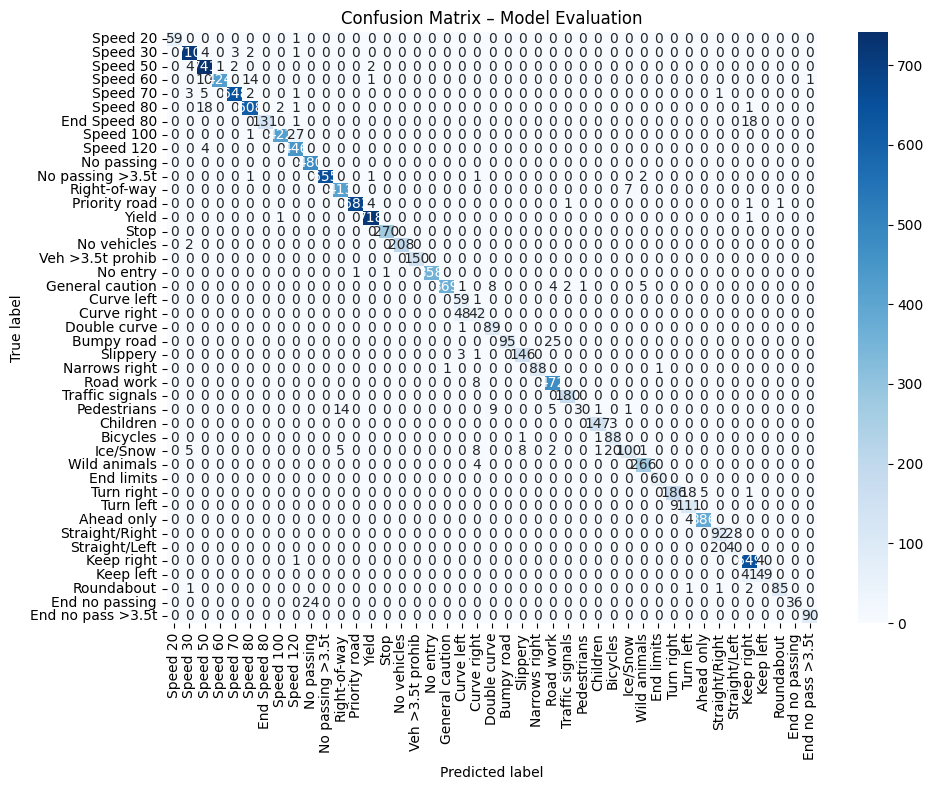

Training model: SimpleCNN_dropout_04
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=8192, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=256, out_features=43, bias=True)
  )
)
Starting training...

Epoch 1/20


Training:   0%|          | 0/307 [00:00<?, ?it/s]/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 1.9311 | Train Acc: 0.4141
Train Time: 133.44s
Val   Loss: 0.9619 | Val   Acc: 0.6665
Val   Time: 23.72s

Epoch 2/20


Train Loss: 0.7589 | Train Acc: 0.7430
Train Time: 153.49s
Val   Loss: 0.4685 | Val   Acc: 0.8444
Val   Time: 20.91s

Epoch 3/20


Train Loss: 0.4217 | Train Acc: 0.8595
Train Time: 138.55s
Val   Loss: 0.3602 | Val   Acc: 0.8854
Val   Time: 25.42s

Epoch 4/20


...

Train Loss: 0.0657 | Train Acc: 0.9784
Train Time: 114.79s
Val   Loss: 0.2065 | Val   Acc: 0.9509
Val   Time: 18.92s

Epoch 17/20


Train Loss: 0.0635 | Train Acc: 0.9787
Train Time: 112.08s
Val   Loss: 0.1864 | Val   Acc: 0.9530
Val   Time: 17.77s

Epoch 18/20


Train Loss: 0.0611 | Train Acc: 0.9803
Train Time: 112.25s
Val   Loss: 0.2171 | Val   Acc: 0.9492
Val   Time: 17.65s

Epoch 19/20


Train Loss: 0.0592 | Train Acc: 0.9806
Train Time: 98.67s
Val   Loss: 0.2149 | Val   Acc: 0.9535
Val   Time: 14.88s

Epoch 20/20


Train Loss: 0.0560 | Train Acc: 0.9812
Train Time: 99.08s
Val   Loss: 0.1933 | Val   Acc: 0.9530
Val   Time: 14.62s

Total Training Time  : 2271.84s
Total Validation Time: 355.33s


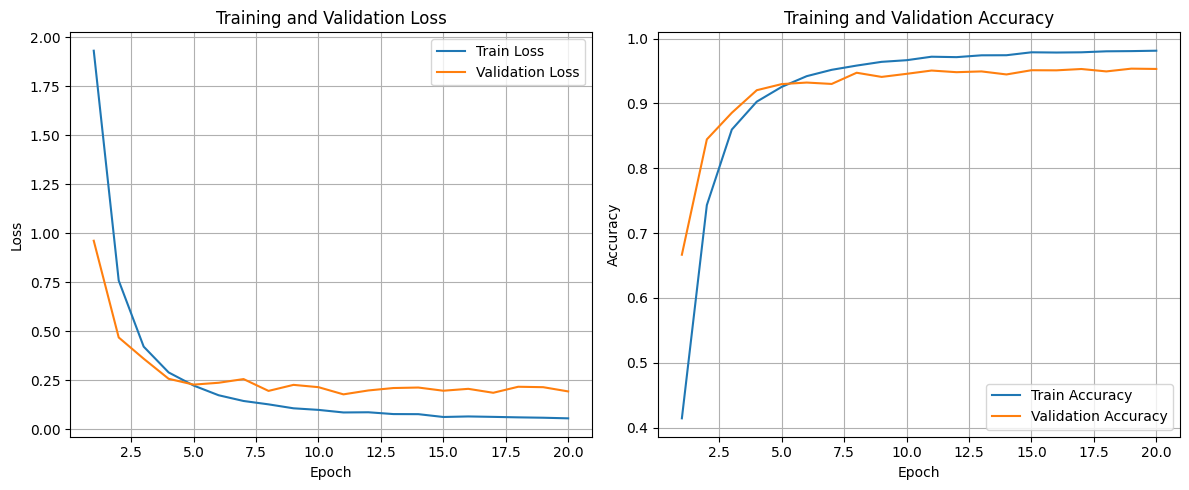

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_dropout_04_gtsrb.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.9530

Model Evaluation
----------------
Overall accuracy: 0.9530

Per-class accuracy:
  Speed 20: 0.867
  Speed 30: 0.992
  Speed 50: 0.979
  Speed 60: 0.904
  Speed 70: 0.973
  Speed 80: 0.957
End Speed 80: 0.900
 Speed 100: 0.960
 Speed 120: 0.991
No passing: 0.996
No passing >3.5t: 0.997
Right-of-way: 0.974
Priority road: 0.981
     Yield: 0.997
      Stop: 1.000
No vehicles: 0.995
Veh >3.5t prohib: 0.987
  No entry: 0.947
General caution: 0.956
Curve left: 1.000
Curve right: 0.378
Double curve: 0.944
Bumpy road: 0.742
  Slippery: 0.993
Narrows right: 0.967
 Road work: 0.975
Traffic signals: 1.000
Pedestrians: 0.500
  Children: 0.967
  Bicycles: 1.000
  Ice/Snow: 0.787
Wild animals: 0.978
End limits: 1.000
Turn right: 0.852
 Turn left: 0.808
Ahead only: 0.992
Straight/Right: 0.842
Straight/Left: 0.650
Keep right: 0.9

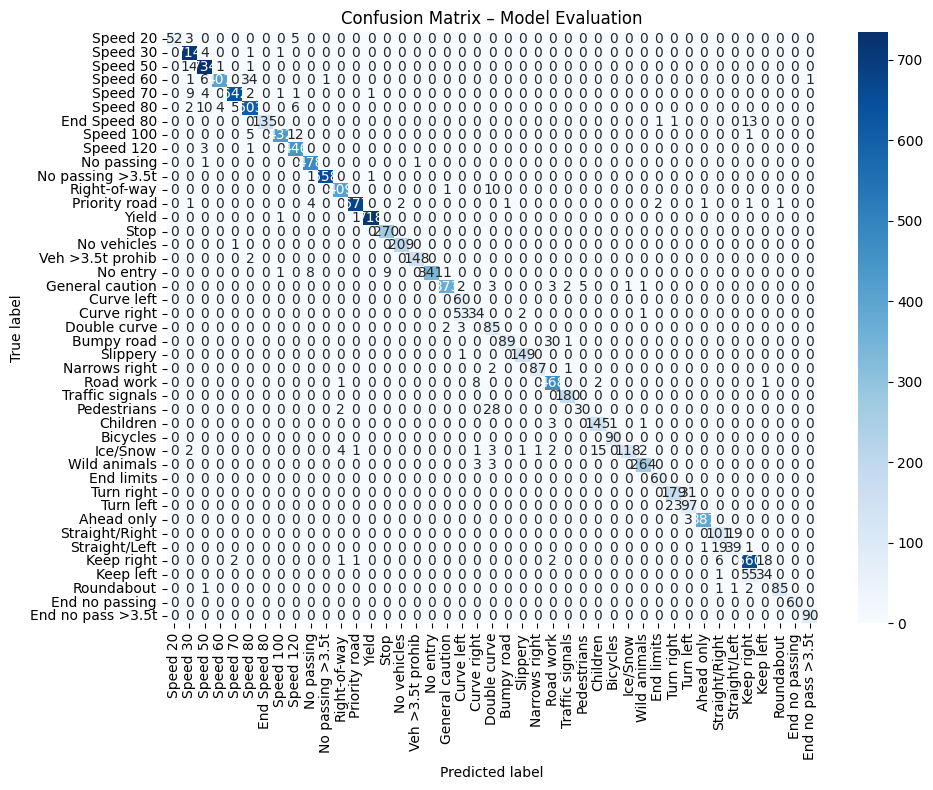

Training model: SimpleCNN_dropout_03
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=8192, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=43, bias=True)
  )
)
Starting training...

Epoch 1/20


Training:   0%|          | 0/307 [00:00<?, ?it/s]/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 1.8675 | Train Acc: 0.4367
Train Time: 104.13s
Val   Loss: 1.0202 | Val   Acc: 0.6461
Val   Time: 16.46s

Epoch 2/20


Train Loss: 0.6758 | Train Acc: 0.7723
Train Time: 104.68s
Val   Loss: 0.4079 | Val   Acc: 0.8609
Val   Time: 15.11s

Epoch 3/20


Train Loss: 0.3572 | Train Acc: 0.8826
Train Time: 110.11s
Val   Loss: 0.3085 | Val   Acc: 0.9066
Val   Time: 20.68s

Epoch 4/20


...

Train Loss: 0.0517 | Train Acc: 0.9834
Train Time: 110.93s
Val   Loss: 0.2647 | Val   Acc: 0.9437
Val   Time: 17.56s

Epoch 17/20


Train Loss: 0.0512 | Train Acc: 0.9839
Train Time: 103.78s
Val   Loss: 0.2384 | Val   Acc: 0.9411
Val   Time: 15.21s

Epoch 18/20


Train Loss: 0.0476 | Train Acc: 0.9842
Train Time: 105.93s
Val   Loss: 0.2495 | Val   Acc: 0.9449
Val   Time: 15.18s

Epoch 19/20


Train Loss: 0.0470 | Train Acc: 0.9840
Train Time: 96.88s
Val   Loss: 0.2212 | Val   Acc: 0.9507
Val   Time: 14.26s

Epoch 20/20


Train Loss: 0.0438 | Train Acc: 0.9858
Train Time: 115.35s
Val   Loss: 0.2811 | Val   Acc: 0.9444
Val   Time: 15.25s

Total Training Time  : 2137.51s
Total Validation Time: 321.35s


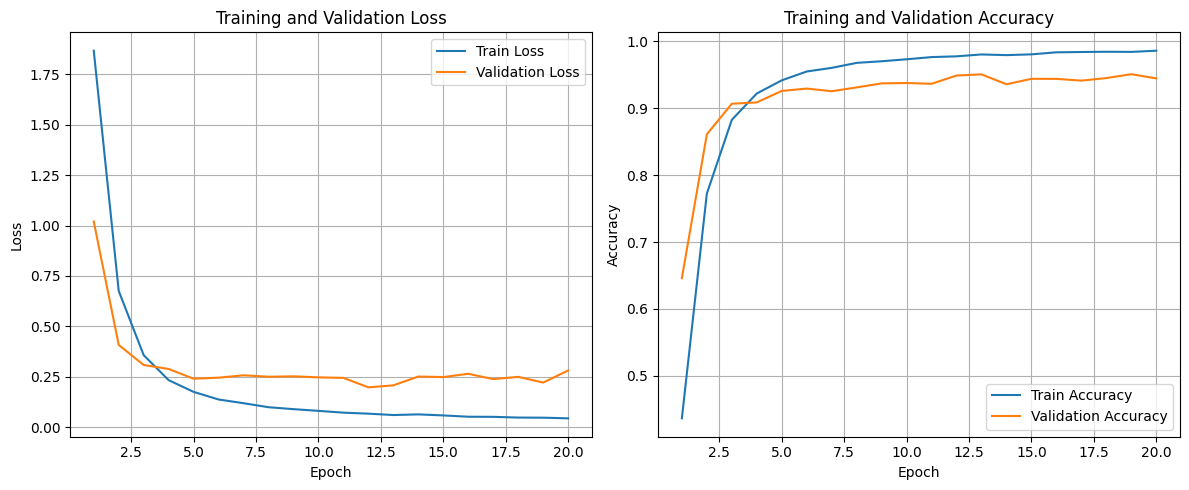

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_dropout_03_gtsrb.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.9444

Model Evaluation
----------------
Overall accuracy: 0.9444

Per-class accuracy:
  Speed 20: 0.950
  Speed 30: 0.988
  Speed 50: 0.963
  Speed 60: 0.980
  Speed 70: 0.955
  Speed 80: 0.979
End Speed 80: 0.880
 Speed 100: 0.931
 Speed 120: 0.956
No passing: 0.994
No passing >3.5t: 0.997
Right-of-way: 0.993
Priority road: 0.975
     Yield: 0.997
      Stop: 1.000
No vehicles: 0.986
Veh >3.5t prohib: 1.000
  No entry: 0.994
General caution: 0.949
Curve left: 0.983
Curve right: 0.433
Double curve: 0.667
Bumpy road: 0.742
  Slippery: 0.993
Narrows right: 0.989
 Road work: 0.996
Traffic signals: 1.000
Pedestrians: 0.517
  Children: 0.960
  Bicycles: 0.967
  Ice/Snow: 0.753
Wild animals: 0.993
End limits: 0.933
Turn right: 0.619
 Turn left: 0.825
Ahead only: 0.962
Straight/Right: 0.608
Straight/Left: 0.400
Keep right: 0.9

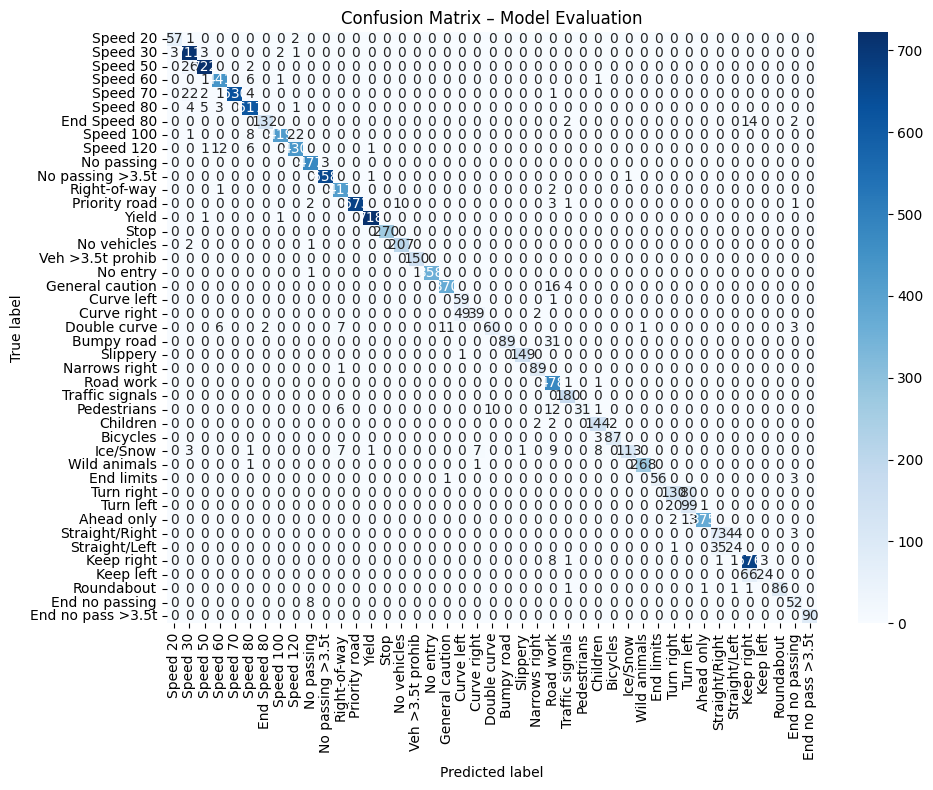

Training model: SimpleCNN_dropout_02
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=8192, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=43, bias=True)
  )
)
Starting training...

Epoch 1/20


Training:   0%|          | 0/307 [00:00<?, ?it/s]/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 1.8193 | Train Acc: 0.4524
Train Time: 96.14s
Val   Loss: 0.8655 | Val   Acc: 0.6999
Val   Time: 14.25s

Epoch 2/20


Train Loss: 0.6546 | Train Acc: 0.7831
Train Time: 93.96s
Val   Loss: 0.4798 | Val   Acc: 0.8401
Val   Time: 14.31s

Epoch 3/20


Train Loss: 0.3761 | Train Acc: 0.8757
Train Time: 99.41s
Val   Loss: 0.3463 | Val   Acc: 0.8875
Val   Time: 15.07s

Epoch 4/20


...

Train Loss: 0.0556 | Train Acc: 0.9818
Train Time: 101.69s
Val   Loss: 0.2326 | Val   Acc: 0.9408
Val   Time: 16.11s

Epoch 17/20


Train Loss: 0.0513 | Train Acc: 0.9831
Train Time: 98.70s
Val   Loss: 0.2176 | Val   Acc: 0.9441
Val   Time: 14.21s

Epoch 18/20


Train Loss: 0.0472 | Train Acc: 0.9847
Train Time: 124.09s
Val   Loss: 0.2232 | Val   Acc: 0.9425
Val   Time: 17.45s

Epoch 19/20


Train Loss: 0.0508 | Train Acc: 0.9829
Train Time: 108.13s
Val   Loss: 0.2144 | Val   Acc: 0.9521
Val   Time: 15.90s

Epoch 20/20


Train Loss: 0.0442 | Train Acc: 0.9853
Train Time: 107.03s
Val   Loss: 0.2539 | Val   Acc: 0.9457
Val   Time: 16.89s

Total Training Time  : 1994.74s
Total Validation Time: 305.32s


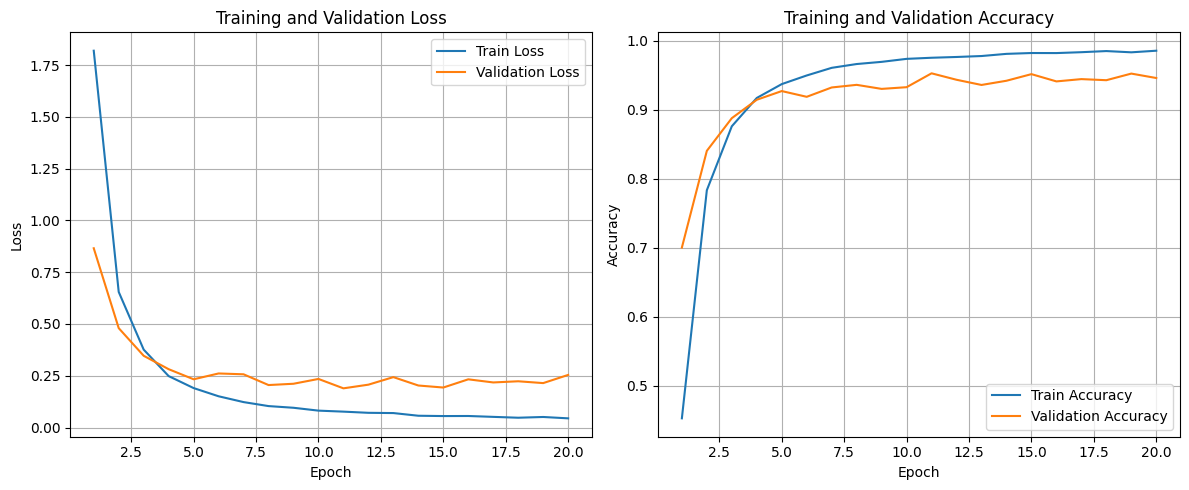

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_dropout_02_gtsrb.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.9457

Model Evaluation
----------------
Overall accuracy: 0.9457

Per-class accuracy:
  Speed 20: 0.733
  Speed 30: 0.976
  Speed 50: 0.983
  Speed 60: 0.911
  Speed 70: 0.979
  Speed 80: 0.975
End Speed 80: 0.880
 Speed 100: 0.920
 Speed 120: 0.960
No passing: 0.996
No passing >3.5t: 0.991
Right-of-way: 0.979
Priority road: 0.972
     Yield: 0.996
      Stop: 1.000
No vehicles: 0.990
Veh >3.5t prohib: 1.000
  No entry: 0.978
General caution: 0.915
Curve left: 0.950
Curve right: 0.489
Double curve: 0.944
Bumpy road: 0.750
  Slippery: 0.820
Narrows right: 0.967
 Road work: 0.971
Traffic signals: 1.000
Pedestrians: 0.500
  Children: 0.960
  Bicycles: 0.978
  Ice/Snow: 0.873
Wild animals: 0.919
End limits: 0.983
Turn right: 0.800
 Turn left: 0.908
Ahead only: 0.969
Straight/Right: 0.867
Straight/Left: 0.333
Keep right: 0.9

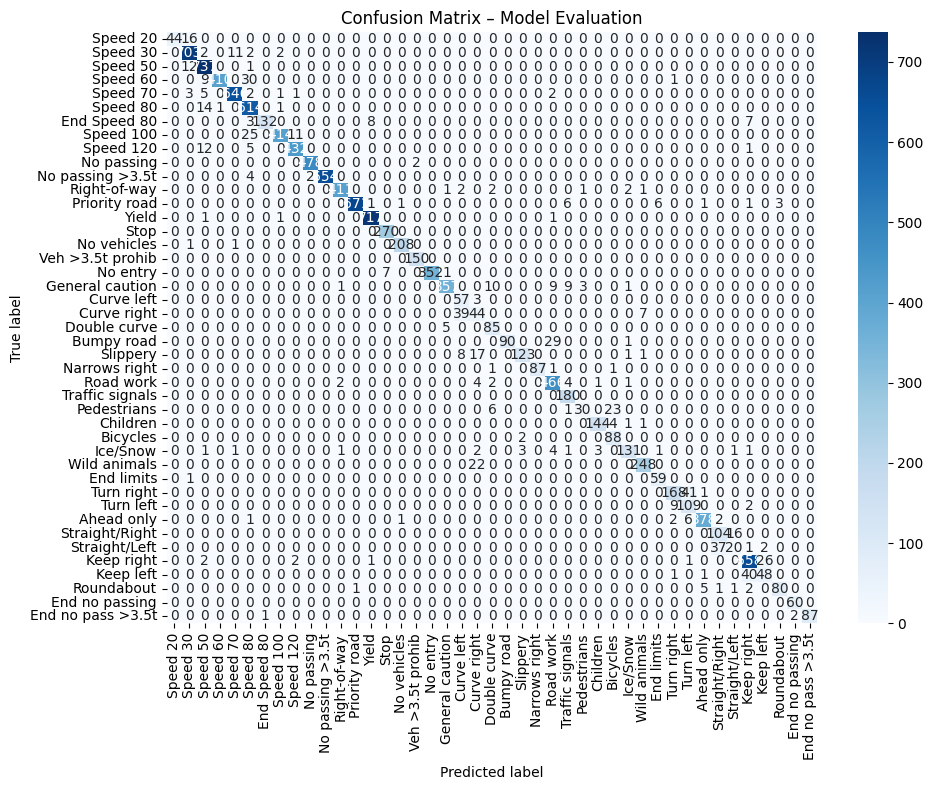

Training model: SimpleCNN_dropout_01
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=8192, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=43, bias=True)
  )
)
Starting training...

Epoch 1/20


Training:   0%|          | 0/307 [00:00<?, ?it/s]/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 1.7029 | Train Acc: 0.4846
Train Time: 126.33s
Val   Loss: 0.8780 | Val   Acc: 0.7030
Val   Time: 18.29s

Epoch 2/20


Train Loss: 0.5298 | Train Acc: 0.8265
Train Time: 112.97s
Val   Loss: 0.3980 | Val   Acc: 0.8780
Val   Time: 16.29s

Epoch 3/20


Train Loss: 0.2639 | Train Acc: 0.9155
Train Time: 108.89s
Val   Loss: 0.3530 | Val   Acc: 0.8890
Val   Time: 15.45s

Epoch 4/20


...

Train Loss: 0.0417 | Train Acc: 0.9857
Train Time: 102.76s
Val   Loss: 0.3132 | Val   Acc: 0.9352
Val   Time: 16.22s

Epoch 17/20


Train Loss: 0.0391 | Train Acc: 0.9867
Train Time: 107.63s
Val   Loss: 0.3041 | Val   Acc: 0.9387
Val   Time: 18.71s

Epoch 18/20


Train Loss: 0.0330 | Train Acc: 0.9891
Train Time: 107.49s
Val   Loss: 0.2653 | Val   Acc: 0.9365
Val   Time: 15.62s

Epoch 19/20


Train Loss: 0.0310 | Train Acc: 0.9897
Train Time: 108.62s
Val   Loss: 0.2538 | Val   Acc: 0.9390
Val   Time: 16.35s

Epoch 20/20


Train Loss: 0.0316 | Train Acc: 0.9903
Train Time: 134.44s
Val   Loss: 0.2270 | Val   Acc: 0.9439
Val   Time: 20.09s

Total Training Time  : 2246.31s
Total Validation Time: 345.36s


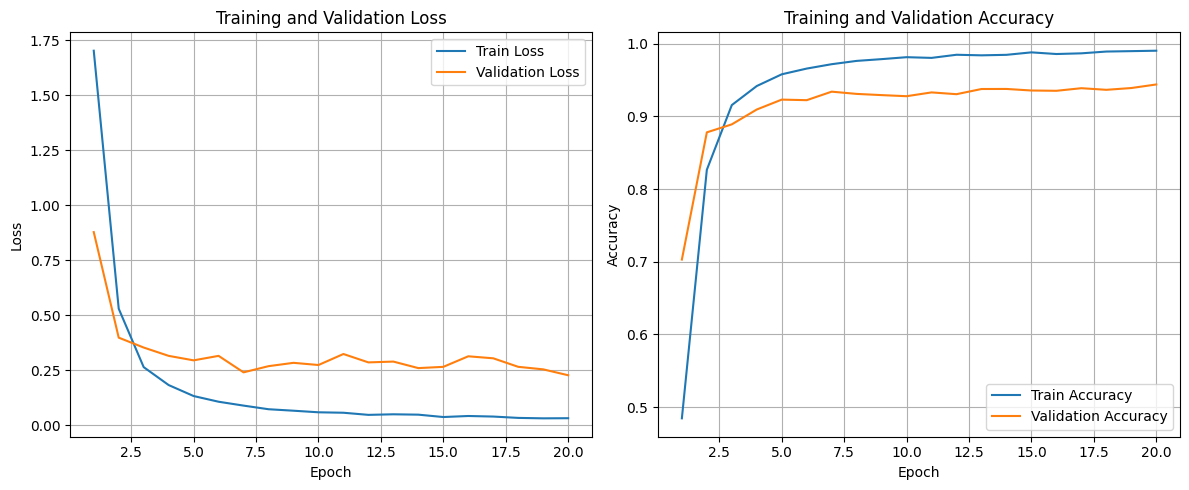

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_dropout_01_gtsrb.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.9439

Model Evaluation
----------------
Overall accuracy: 0.9439

Per-class accuracy:
  Speed 20: 0.867
  Speed 30: 0.993
  Speed 50: 0.977
  Speed 60: 0.960
  Speed 70: 0.976
  Speed 80: 0.965
End Speed 80: 0.867
 Speed 100: 0.971
 Speed 120: 0.964
No passing: 0.992
No passing >3.5t: 0.998
Right-of-way: 0.988
Priority road: 0.990
     Yield: 0.997
      Stop: 1.000
No vehicles: 0.971
Veh >3.5t prohib: 1.000
  No entry: 0.947
General caution: 0.931
Curve left: 0.150
Curve right: 0.700
Double curve: 0.789
Bumpy road: 0.750
  Slippery: 0.707
Narrows right: 0.878
 Road work: 0.975
Traffic signals: 0.994
Pedestrians: 0.500
  Children: 0.953
  Bicycles: 1.000
  Ice/Snow: 0.893
Wild animals: 0.963
End limits: 1.000
Turn right: 0.571
 Turn left: 1.000
Ahead only: 0.969
Straight/Right: 0.583
Straight/Left: 0.550
Keep right: 0.9

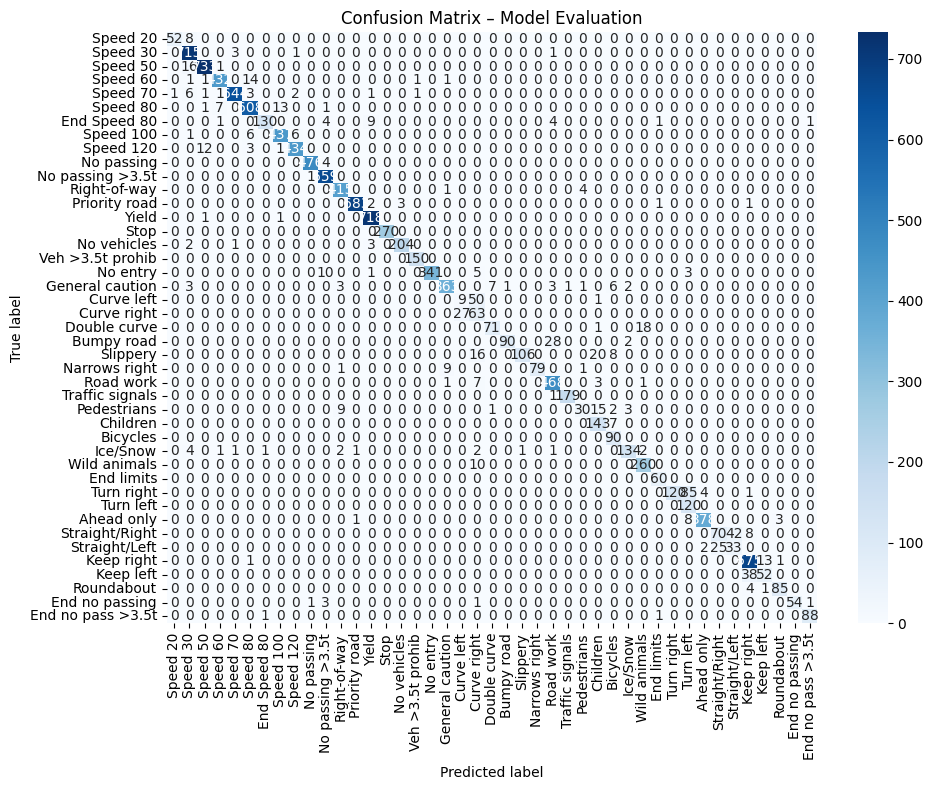

Training model: SimpleCNN_dropout_00
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=8192, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=256, out_features=43, bias=True)
  )
)
Starting training...

Epoch 1/20


Training:   0%|          | 0/307 [00:00<?, ?it/s]/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 1.6360 | Train Acc: 0.5061
Train Time: 121.34s
Val   Loss: 0.8375 | Val   Acc: 0.7363
Val   Time: 17.90s

Epoch 2/20


Train Loss: 0.4957 | Train Acc: 0.8363
Train Time: 101.30s
Val   Loss: 0.4603 | Val   Acc: 0.8614
Val   Time: 17.79s

Epoch 3/20


Train Loss: 0.2653 | Train Acc: 0.9135
Train Time: 103.69s
Val   Loss: 0.4288 | Val   Acc: 0.8782
Val   Time: 16.37s

Epoch 4/20


...

Train Loss: 0.0344 | Train Acc: 0.9888
Train Time: 92.73s
Val   Loss: 0.2739 | Val   Acc: 0.9375
Val   Time: 14.21s

Epoch 17/20


Train Loss: 0.0314 | Train Acc: 0.9902
Train Time: 93.49s
Val   Loss: 0.2700 | Val   Acc: 0.9340
Val   Time: 14.11s

Epoch 18/20


Train Loss: 0.0303 | Train Acc: 0.9909
Train Time: 92.31s
Val   Loss: 0.2835 | Val   Acc: 0.9325
Val   Time: 14.18s

Epoch 19/20


Train Loss: 0.0313 | Train Acc: 0.9900
Train Time: 93.09s
Val   Loss: 0.2856 | Val   Acc: 0.9323
Val   Time: 15.37s

Epoch 20/20


Train Loss: 0.0284 | Train Acc: 0.9909
Train Time: 102.22s
Val   Loss: 0.3193 | Val   Acc: 0.9338
Val   Time: 16.20s

Total Training Time  : 2115.72s
Total Validation Time: 330.05s


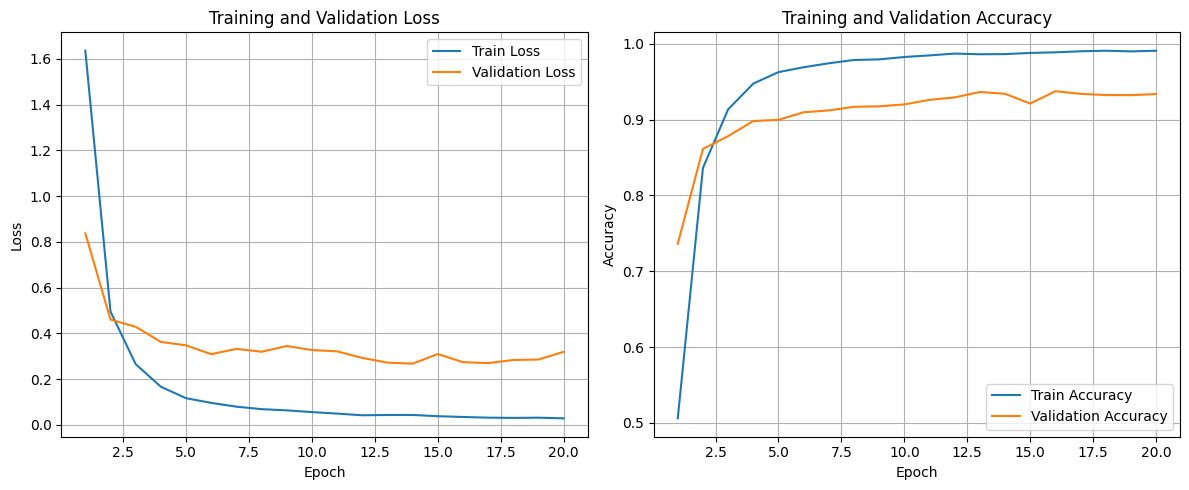

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_dropout_00_gtsrb.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.9338

Model Evaluation
----------------
Overall accuracy: 0.9338

Per-class accuracy:
  Speed 20: 0.817
  Speed 30: 0.976
  Speed 50: 0.945
  Speed 60: 0.958
  Speed 70: 0.956
  Speed 80: 0.963
End Speed 80: 0.853
 Speed 100: 0.911
 Speed 120: 0.971
No passing: 0.994
No passing >3.5t: 0.994
Right-of-way: 0.990
Priority road: 0.994
     Yield: 0.972
      Stop: 0.996
No vehicles: 0.981
Veh >3.5t prohib: 1.000
  No entry: 0.897
General caution: 0.877
Curve left: 0.850
Curve right: 0.478
Double curve: 0.667
Bumpy road: 0.833
  Slippery: 0.853
Narrows right: 0.956
 Road work: 0.967
Traffic signals: 0.994
Pedestrians: 0.500
  Children: 0.960
  Bicycles: 0.944
  Ice/Snow: 0.647
Wild animals: 0.978
End limits: 1.000
Turn right: 0.838
 Turn left: 0.842
Ahead only: 0.897
Straight/Right: 0.717
Straight/Left: 0.433
Keep right: 0.9

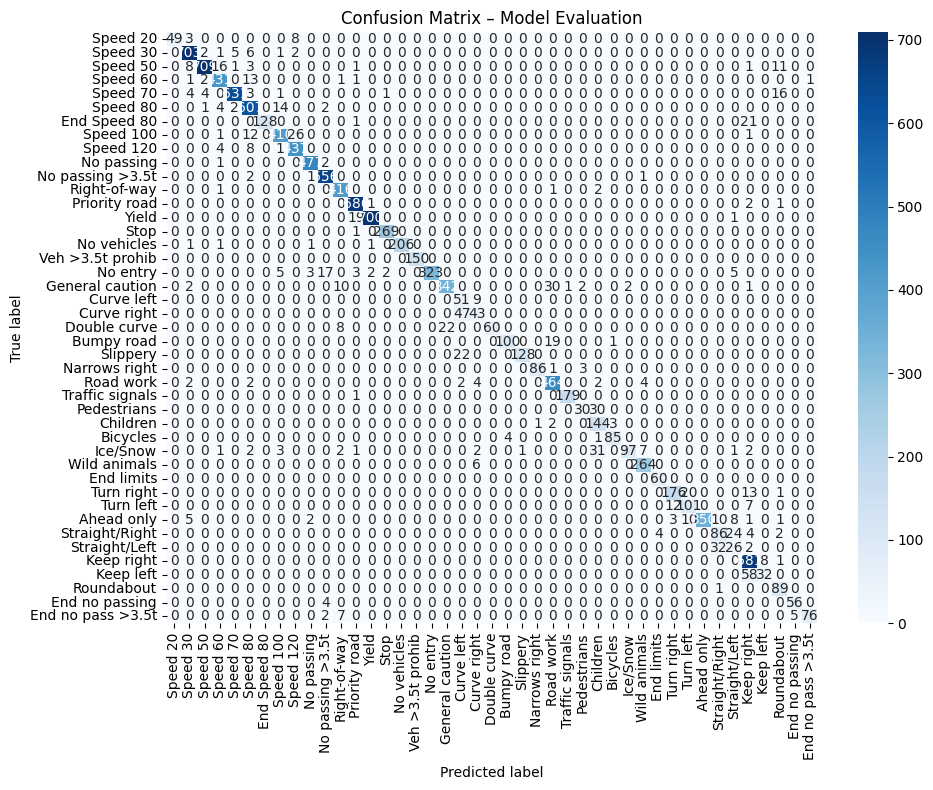

In [3]:
in_channels = 3
num_classes = len(GTSRB_CLASSES)
input_size = 64
base_channels = 32
channel_multiplier = 2
epochs=20

model_selection = { "SimpleCNN_dropout_05": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                input_size=input_size,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.5),
                    "SimpleCNN_dropout_04": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                input_size=input_size,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.4), 
                    "SimpleCNN_dropout_03": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                input_size=input_size,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.3), 
                    "SimpleCNN_dropout_02": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                input_size=input_size,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.2), 
                    "SimpleCNN_dropout_01": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                input_size=input_size,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.1), 
                    "SimpleCNN_dropout_00": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                input_size=input_size,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.0)}
iteration = 2
for model_name, model in model_selection.items():
    print(f"Training model: {model_name}")
    # Set the model to the device (GPU/CPU)
    model = model.to(device)
    print(model)

    # Prepare Loss function and optimizer
    criterion = nn.CrossEntropyLoss() # loss function cross entropy that will be used for calculating the loss during training so that the optimizer can update the weights accordingly (remember backpropagation!)

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    print("Starting training...")
    # Train the model
    trained_model = train_model(
        model=model,
        trainloader=trainloader,
        valloader=valloader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        epochs=epochs#*iteration
        )
    print("Training completed.")    

    # Save the trained model and check for exisiting files/dirs 
    Path("cnn_trained_models").mkdir(exist_ok=True)
    file_name = f"cnn_trained_models/{model_name.lower()}_gtsrb.pth"
    
    # Check if file exists and append version number
    base_path = Path(file_name)
    if base_path.exists():
        version = 1
        while (base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}").exists():
            version += 1
        file_name = str(base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}")

    torch.save(trained_model.state_dict(), file_name)
    print("Saved trained model to:", file_name)
    
    print("Evaluating trained model on validation set...")
    trained_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = trained_model(images)
            _, preds = outputs.max(1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    print(f"Final validation accuracy: {correct / total:.4f}")

    evaluate_model(trained_model, valloader, device=device, class_names=class_names)
    iteration += 1
    del trained_model

### Analysis Area

#### Epoch Analysis

In [ ]:
epochs = [10, 15, 20, 25] 
data = {
    # [0.9612, 0.9713, 0.9745, 0.9694, 0.9747],
    "SimpleCNN_noAug": [0.9713, 0.9745, 0.9694, 0.9747],
    "SimpleCNN_Aug": [0.9477, 0.9599, 0.9537, 0.9625]
}

plt.figure(figsize=(8, 5))

for label, values in data.items():
    plt.plot(epochs, values, marker=".", linestyle="--", linewidth=1, label=label)

    for x, y in zip(epochs, values): 
        plt.text(
            x, 
            y + 0.0002, 
            f"{y:.3f}",
            ha="center", va="bottom", fontsize=8)
        
plt.xlabel("Epochs")
plt.ylabel("Validation Error")
plt.title("Validation Error vs Epochs")
plt.legend()
plt.grid(linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


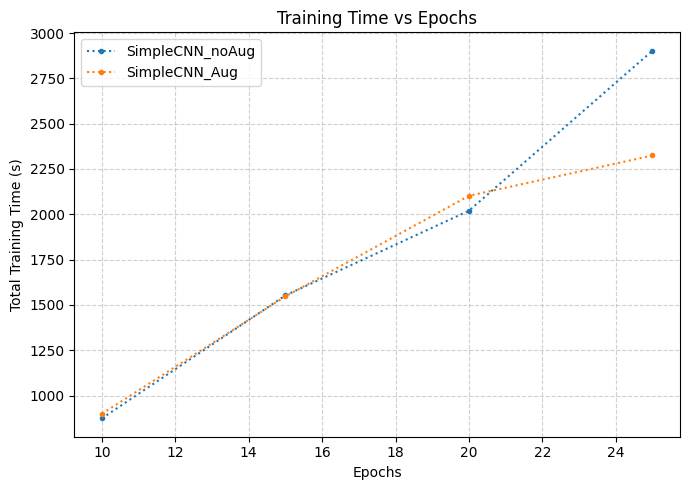

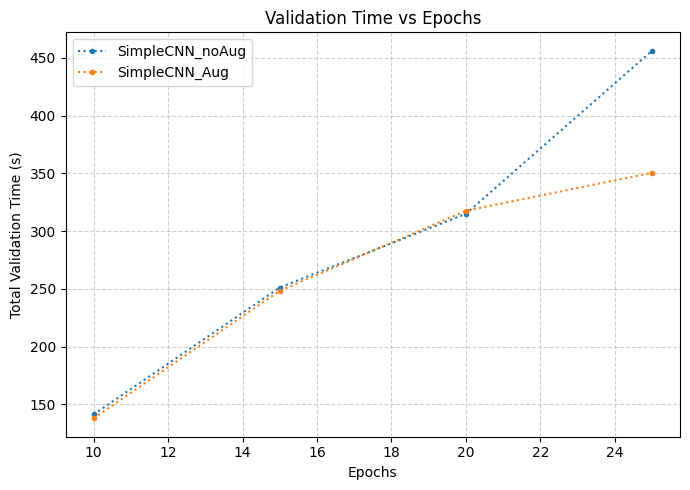

In [4]:
# Epochs
epochs = [10, 15, 20, 25] # potentially remove 5 just to be in line with the other analysis

# Extracted data in order of epochs above
train_times = {
                    # [471.32, 874.48, 1552.71, 2019.76, 2902.53],
    "SimpleCNN_noAug": [ 874.48, 1552.71, 2019.76, 2902.53],
    "SimpleCNN_Aug": [899.77, 1547.42, 2102.18, 2324.52]
}

val_times = {
                    # [73.79, 141.15, 251.09, 314.96, 456.18],
    "SimpleCNN_noAug": [141.15, 251.09, 314.96, 456.18],
    "SimpleCNN_Aug": [137.78, 248.24, 317.56, 350.46]
}

# Training time plot
plt.figure(figsize=(7, 5))
for label, values in train_times.items():
    plt.plot(epochs, values, marker=".", label=label, linestyle=":")

plt.xlabel("Epochs")
plt.ylabel("Total Training Time (s)")
plt.title("Training Time vs Epochs")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Validation time plot
plt.figure(figsize=(7, 5))
for label, values in val_times.items():
    plt.plot(epochs, values, marker=".", label=label, linestyle=":")

plt.xlabel("Epochs")
plt.ylabel("Total Validation Time (s)")
plt.title("Validation Time vs Epochs")
plt.legend()
plt.grid(True,linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

#### Dropout Analysis

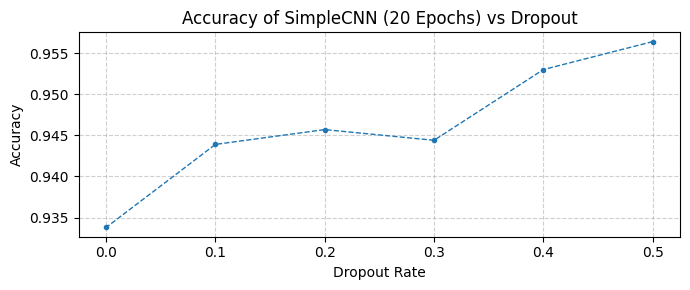

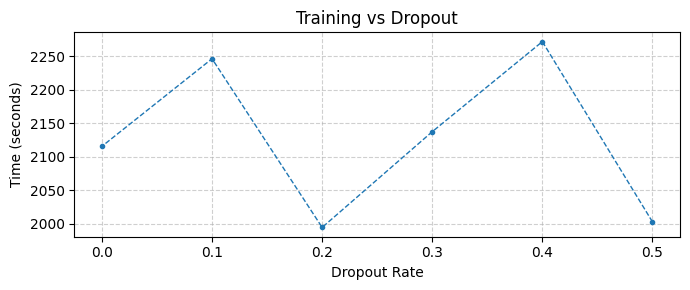

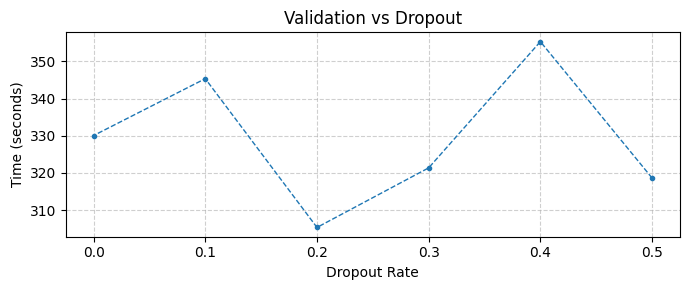

In [5]:
dropout_model_accuracy = {
    "SimpleCNN_dropout_05": 0.9564, 
    "SimpleCNN_dropout_04": 0.9530, 
    "SimpleCNN_dropout_03": 0.9444,       
    "SimpleCNN_dropout_02": 0.9457,
    "SimpleCNN_dropout_01": 0.9439,   
    "SimpleCNN_dropout_00": 0.9338
    }

# (train, val)        
dropout_model_training_validation_time = {               
    "SimpleCNN_dropout_05": (2003.03, 318.62), 
    "SimpleCNN_dropout_04": (2271.84, 355.33), 
    "SimpleCNN_dropout_03": (2137.51, 321.35),       
    "SimpleCNN_dropout_02": (1994.74, 305.32),  
    "SimpleCNN_dropout_01": (2246.31, 345.36),
    "SimpleCNN_dropout_00": (2115.72, 330.05)
    }


# Extract dropout values from the name
dropout_values = np.array([int(k[-2:]) / 10 for k in dropout_model_accuracy.keys()])
accuracies = np.array(list(dropout_model_accuracy.values()))

# Accuracy Plot
plt.figure(figsize=(7, 3))
plt.plot(dropout_values, accuracies, marker=".", linestyle="--", linewidth=1)

plt.xlabel("Dropout Rate")
plt.ylabel("Accuracy")
plt.title("Accuracy of SimpleCNN (20 Epochs) vs Dropout")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(dropout_values)
plt.tight_layout()
plt.show()

# Training & Validation Time Plot
train_times = [v[0] for v in dropout_model_training_validation_time.values()]
val_times = [v[1] for v in dropout_model_training_validation_time.values()]

plt.figure(figsize=(7, 3))
plt.plot(dropout_values, train_times, marker=".", linestyle="--", linewidth=1, label="Training Time")

plt.xlabel("Dropout Rate")
plt.ylabel("Time (seconds)")
plt.title("Training vs Dropout")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(dropout_values)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3))
plt.plot(dropout_values, val_times, marker=".", linestyle="--", linewidth=1, label="Validation Time")

plt.xlabel("Dropout Rate")
plt.ylabel("Time (seconds)")
plt.title("Validation vs Dropout")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(dropout_values)
plt.tight_layout()
plt.show()